# Practical 6: Density-Based Clustering (DBSCAN)
## Perform DBSCAN on Mall Customers Dataset and Evaluate Cluster Quality

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

## Load and Explore the Mall Customers Dataset

In [6]:
# Load the dataset
df = pd.read_excel('Mall Customers.xlsx')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (200, 7)

Column Names: ['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [7]:
# Dataset statistics
print("Dataset Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Prepare Data for Clustering

In [8]:
# Select features for clustering (Annual Income and Spending Score)
# These are the most relevant features for customer segmentation
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected: Annual Income (k$), Spending Score (1-100)")
print("Scaled data shape:", X_scaled.shape)

Features selected: Annual Income (k$), Spending Score (1-100)
Scaled data shape: (200, 2)


## Determine Optimal Epsilon (eps) using K-Distance Graph

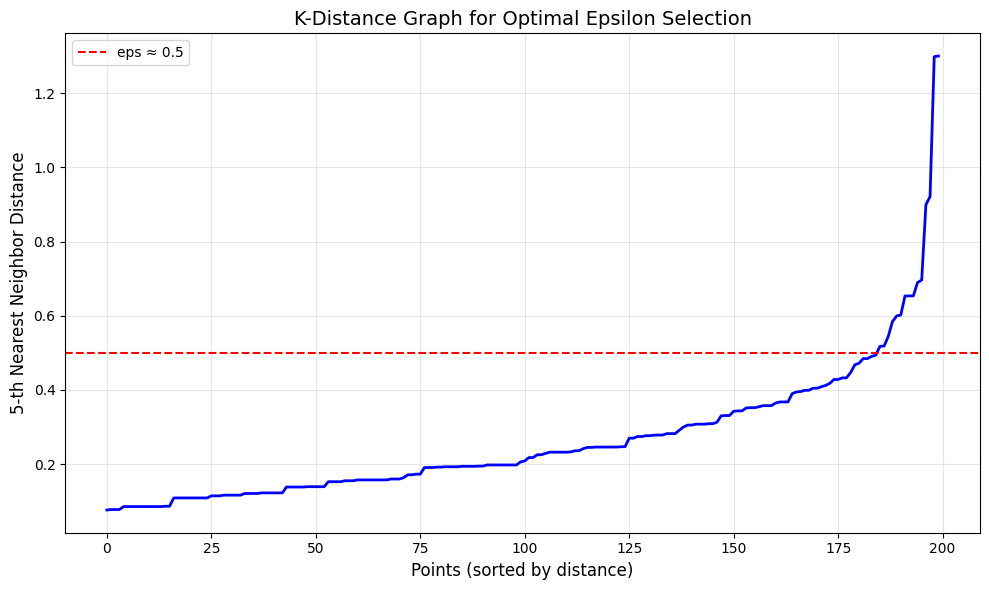

Suggested eps value: Look for the 'elbow' in the curve (approximately 0.4-0.6)


In [9]:
# K-distance graph to find optimal eps
# The "elbow" point suggests a good eps value
k = 5  # min_samples - 1
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 6))
plt.plot(range(len(k_distances)), k_distances, 'b-', linewidth=2)
plt.xlabel('Points (sorted by distance)', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Graph for Optimal Epsilon Selection', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', label='eps ≈ 0.5')
plt.legend()
plt.tight_layout()
plt.show()

print("Suggested eps value: Look for the 'elbow' in the curve (approximately 0.4-0.6)")

## Apply DBSCAN with Default Parameters

In [10]:
# Apply DBSCAN with initial parameters
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Count clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"DBSCAN Results (eps=0.5, min_samples=5):")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Cluster distribution: {pd.Series(labels).value_counts().sort_index().to_dict()}")

DBSCAN Results (eps=0.5, min_samples=5):
Number of clusters: 2
Number of noise points: 8
Cluster distribution: {-1: 8, 0: 157, 1: 35}


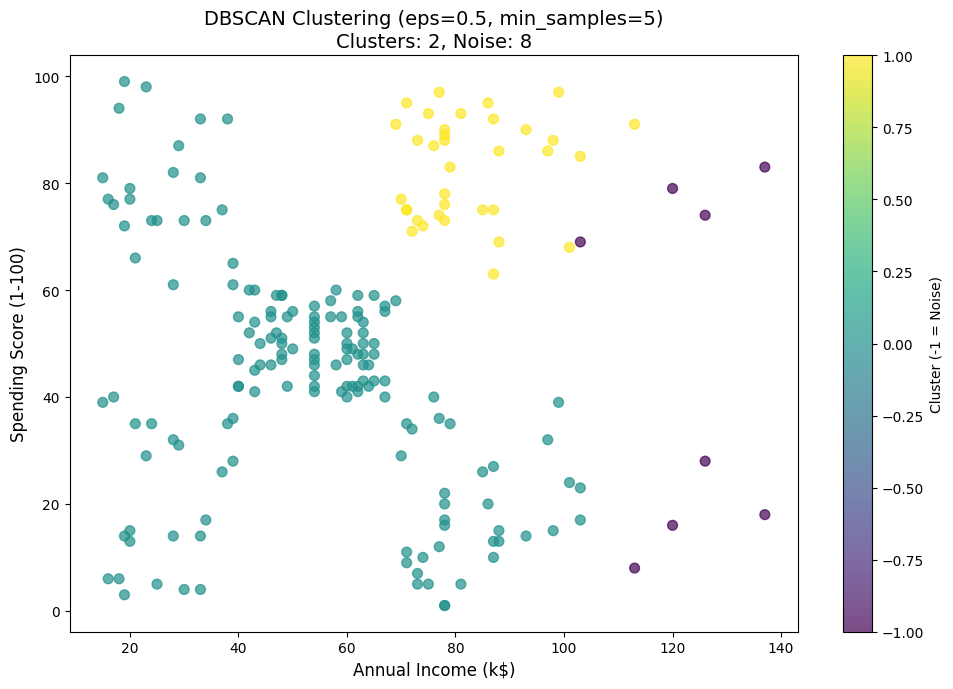

In [11]:
# Visualize the clustering result
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, s=50)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'DBSCAN Clustering (eps=0.5, min_samples=5)\nClusters: {n_clusters}, Noise: {n_noise}', fontsize=14)
plt.colorbar(scatter, label='Cluster (-1 = Noise)')
plt.tight_layout()
plt.show()

## Evaluate Cluster Quality by Varying Epsilon (eps)

In [12]:
# Function to evaluate DBSCAN clustering quality
def evaluate_dbscan(X, eps, min_samples):
    """
    Apply DBSCAN and return evaluation metrics
    """
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Calculate metrics only if we have at least 2 clusters and not all points are noise
    if n_clusters >= 2 and n_noise < len(X):
        # Filter out noise for metric calculation
        mask = labels != -1
        if len(set(labels[mask])) >= 2:
            silhouette = silhouette_score(X[mask], labels[mask])
            calinski = calinski_harabasz_score(X[mask], labels[mask])
            davies = davies_bouldin_score(X[mask], labels[mask])
        else:
            silhouette, calinski, davies = None, None, None
    else:
        silhouette, calinski, davies = None, None, None
    
    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette': silhouette,
        'calinski_harabasz': calinski,
        'davies_bouldin': davies,
        'labels': labels
    }

In [14]:
# Vary epsilon values
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
min_samples_fixed = 5

eps_results = []
for eps in eps_values:
    result = evaluate_dbscan(X_scaled, eps, min_samples_fixed)
    result['eps'] = eps
    result['min_samples'] = min_samples_fixed
    eps_results.append(result)
    sil_str = f"{result['silhouette']:.3f}" if result['silhouette'] else 'N/A'
    print(f"eps={eps}: Clusters={result['n_clusters']}, Noise={result['n_noise']}, Silhouette={sil_str}")

eps=0.2: Clusters=7, Noise=77, Silhouette=0.586
eps=0.3: Clusters=7, Noise=35, Silhouette=0.524
eps=0.4: Clusters=4, Noise=15, Silhouette=0.478
eps=0.5: Clusters=2, Noise=8, Silhouette=0.388
eps=0.6: Clusters=1, Noise=5, Silhouette=N/A
eps=0.7: Clusters=1, Noise=0, Silhouette=N/A
eps=0.8: Clusters=1, Noise=0, Silhouette=N/A
eps=1.0: Clusters=1, Noise=0, Silhouette=N/A


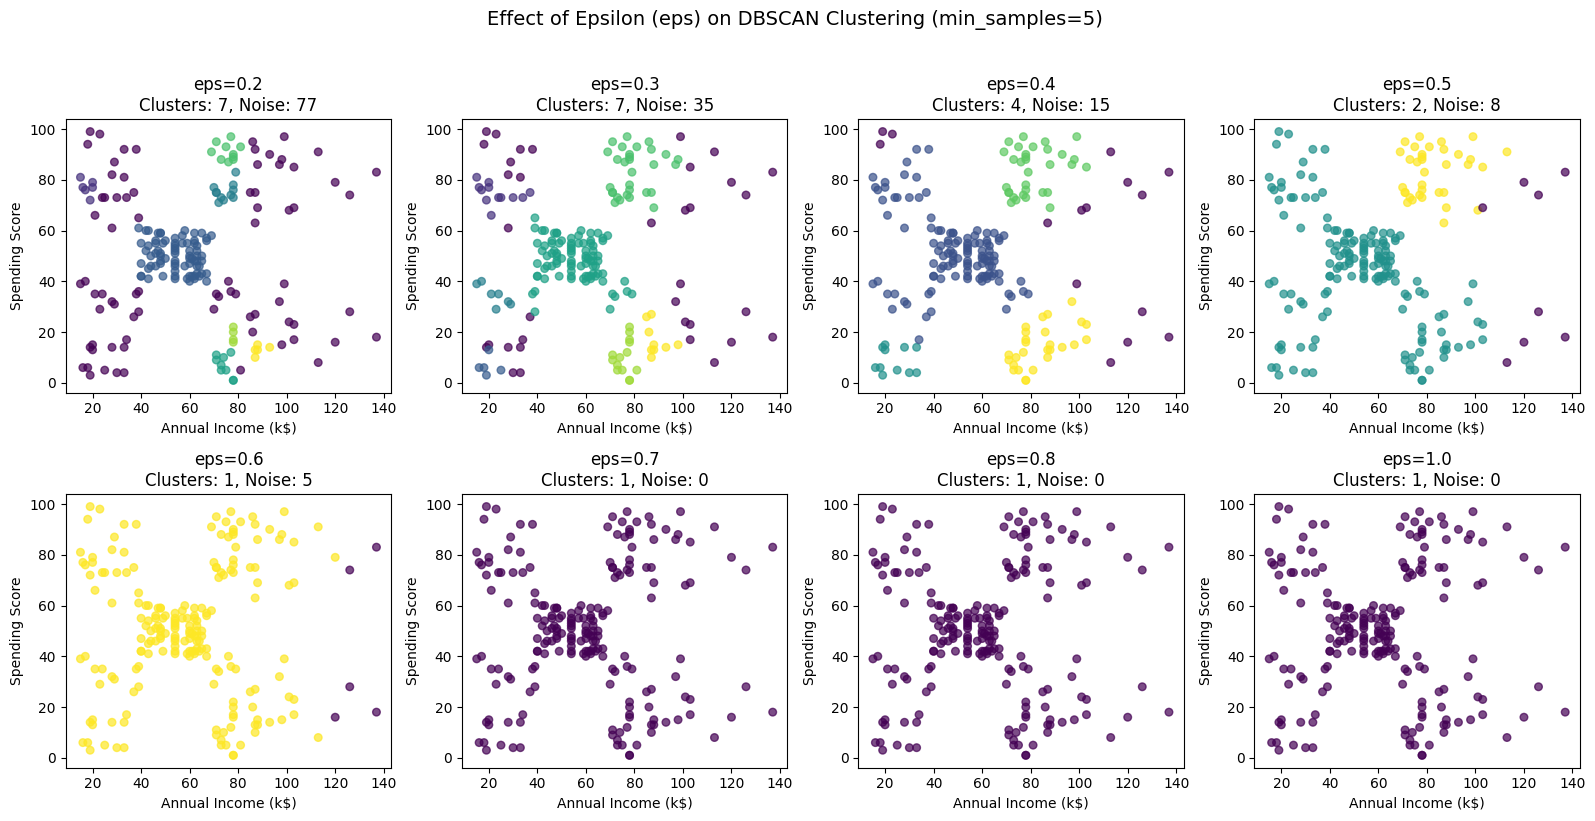

In [15]:
# Plot effect of eps on clustering
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, result in enumerate(eps_results):
    ax = axes[i]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=result['labels'], cmap='viridis', alpha=0.7, s=30)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score')
    ax.set_title(f"eps={result['eps']}\nClusters: {result['n_clusters']}, Noise: {result['n_noise']}")

plt.suptitle('Effect of Epsilon (eps) on DBSCAN Clustering (min_samples=5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Evaluate Cluster Quality by Varying min_samples

In [16]:
# Vary min_samples values
min_samples_values = [3, 4, 5, 6, 7, 8, 10, 15]
eps_fixed = 0.5

min_samples_results = []
for min_samples in min_samples_values:
    result = evaluate_dbscan(X_scaled, eps_fixed, min_samples)
    result['eps'] = eps_fixed
    result['min_samples'] = min_samples
    min_samples_results.append(result)
    sil_str = f"{result['silhouette']:.3f}" if result['silhouette'] else 'N/A'
    print(f"min_samples={min_samples}: Clusters={result['n_clusters']}, Noise={result['n_noise']}, Silhouette={sil_str}")

min_samples=3: Clusters=2, Noise=7, Silhouette=0.389
min_samples=4: Clusters=2, Noise=8, Silhouette=0.388
min_samples=5: Clusters=2, Noise=8, Silhouette=0.388
min_samples=6: Clusters=2, Noise=11, Silhouette=0.401
min_samples=7: Clusters=2, Noise=12, Silhouette=0.394
min_samples=8: Clusters=2, Noise=15, Silhouette=0.401
min_samples=10: Clusters=4, Noise=21, Silhouette=0.511
min_samples=15: Clusters=4, Noise=44, Silhouette=0.591


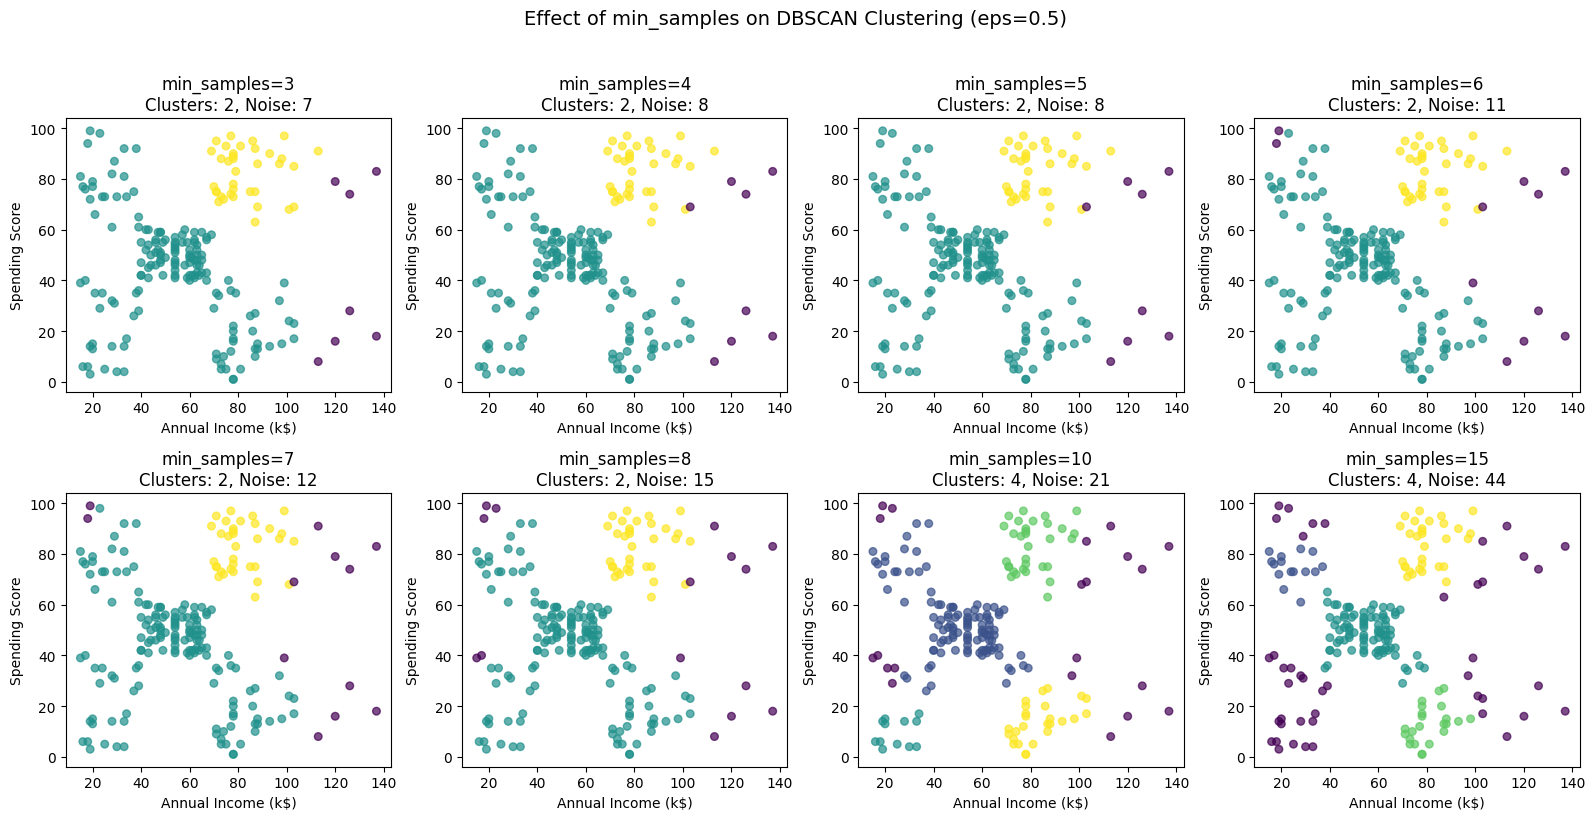

In [17]:
# Plot effect of min_samples on clustering
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, result in enumerate(min_samples_results):
    ax = axes[i]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=result['labels'], cmap='viridis', alpha=0.7, s=30)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score')
    ax.set_title(f"min_samples={result['min_samples']}\nClusters: {result['n_clusters']}, Noise: {result['n_noise']}")

plt.suptitle('Effect of min_samples on DBSCAN Clustering (eps=0.5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Cluster Quality Metrics Comparison

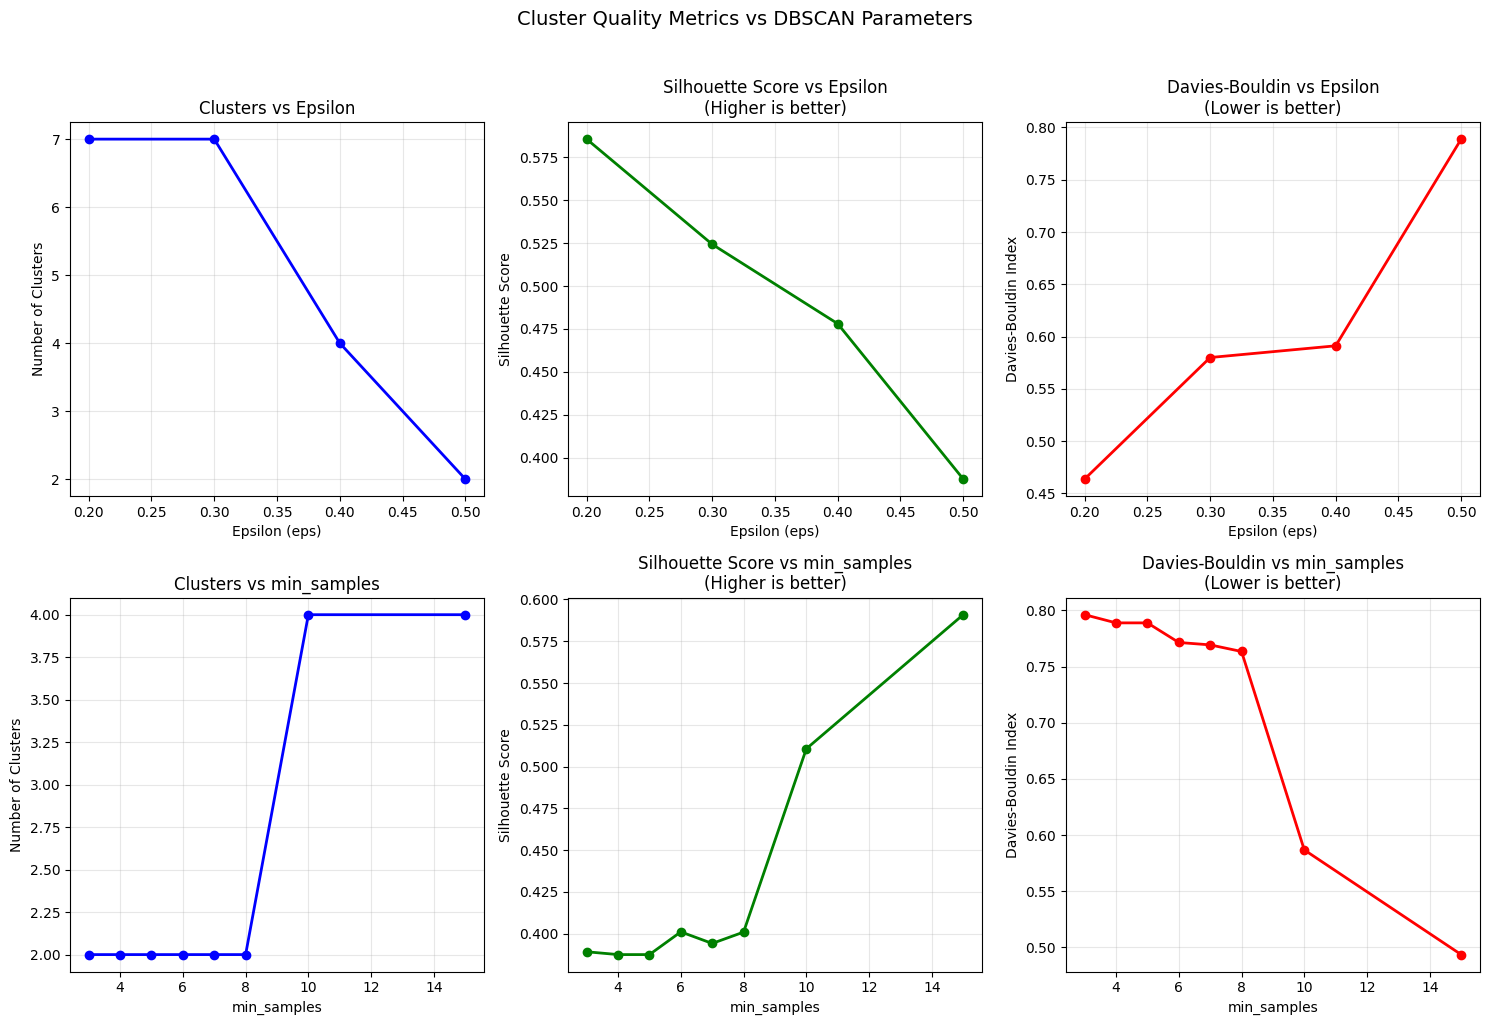

In [18]:
# Create comparison plots for cluster quality metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Metrics vs eps
valid_eps = [r for r in eps_results if r['silhouette'] is not None]
if valid_eps:
    eps_vals = [r['eps'] for r in valid_eps]
    
    axes[0, 0].plot(eps_vals, [r['n_clusters'] for r in valid_eps], 'b-o', linewidth=2)
    axes[0, 0].set_xlabel('Epsilon (eps)')
    axes[0, 0].set_ylabel('Number of Clusters')
    axes[0, 0].set_title('Clusters vs Epsilon')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(eps_vals, [r['silhouette'] for r in valid_eps], 'g-o', linewidth=2)
    axes[0, 1].set_xlabel('Epsilon (eps)')
    axes[0, 1].set_ylabel('Silhouette Score')
    axes[0, 1].set_title('Silhouette Score vs Epsilon\n(Higher is better)')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[0, 2].plot(eps_vals, [r['davies_bouldin'] for r in valid_eps], 'r-o', linewidth=2)
    axes[0, 2].set_xlabel('Epsilon (eps)')
    axes[0, 2].set_ylabel('Davies-Bouldin Index')
    axes[0, 2].set_title('Davies-Bouldin vs Epsilon\n(Lower is better)')
    axes[0, 2].grid(True, alpha=0.3)

# Metrics vs min_samples
valid_ms = [r for r in min_samples_results if r['silhouette'] is not None]
if valid_ms:
    ms_vals = [r['min_samples'] for r in valid_ms]
    
    axes[1, 0].plot(ms_vals, [r['n_clusters'] for r in valid_ms], 'b-o', linewidth=2)
    axes[1, 0].set_xlabel('min_samples')
    axes[1, 0].set_ylabel('Number of Clusters')
    axes[1, 0].set_title('Clusters vs min_samples')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(ms_vals, [r['silhouette'] for r in valid_ms], 'g-o', linewidth=2)
    axes[1, 1].set_xlabel('min_samples')
    axes[1, 1].set_ylabel('Silhouette Score')
    axes[1, 1].set_title('Silhouette Score vs min_samples\n(Higher is better)')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 2].plot(ms_vals, [r['davies_bouldin'] for r in valid_ms], 'r-o', linewidth=2)
    axes[1, 2].set_xlabel('min_samples')
    axes[1, 2].set_ylabel('Davies-Bouldin Index')
    axes[1, 2].set_title('Davies-Bouldin vs min_samples\n(Lower is better)')
    axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Cluster Quality Metrics vs DBSCAN Parameters', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Find Optimal Parameters

In [19]:
# Grid search for best parameters
eps_range = [0.3, 0.4, 0.5, 0.6, 0.7]
min_samples_range = [3, 4, 5, 6, 7]

best_silhouette = -1
best_params = None
all_results = []

for eps in eps_range:
    for min_samples in min_samples_range:
        result = evaluate_dbscan(X_scaled, eps, min_samples)
        result['eps'] = eps
        result['min_samples'] = min_samples
        all_results.append(result)
        
        if result['silhouette'] is not None and result['silhouette'] > best_silhouette:
            best_silhouette = result['silhouette']
            best_params = (eps, min_samples)

print(f"Best Parameters: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"Best Silhouette Score: {best_silhouette:.4f}")

Best Parameters: eps=0.3, min_samples=7
Best Silhouette Score: 0.6452


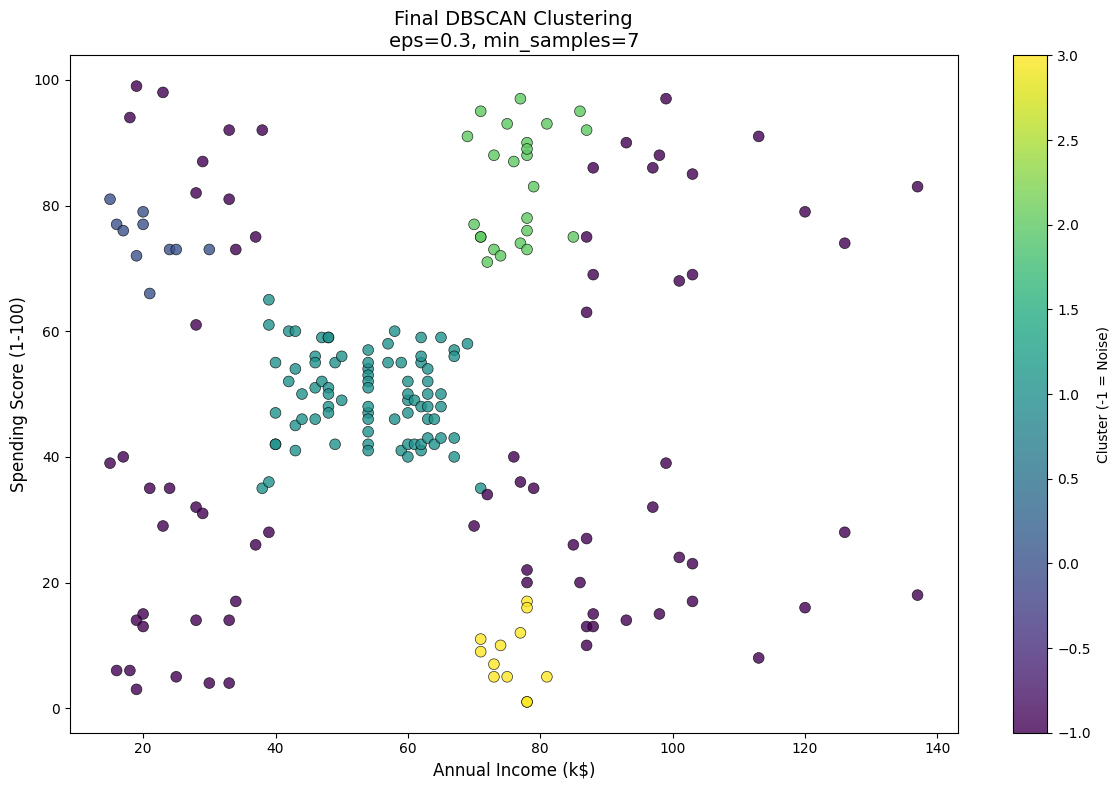


Final Clustering Results:
Number of clusters: 4
Noise points: 72 (36.0%)
Silhouette Score: 0.6452


In [20]:
# Final clustering with best parameters
best_eps, best_min_samples = best_params
final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
final_labels = final_dbscan.fit_predict(X_scaled)

# Visualize final result
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis', alpha=0.8, s=60, edgecolors='black', linewidths=0.5)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'Final DBSCAN Clustering\neps={best_eps}, min_samples={best_min_samples}', fontsize=14)
plt.colorbar(scatter, label='Cluster (-1 = Noise)')
plt.tight_layout()
plt.show()

# Final statistics
n_clusters_final = len(set(final_labels)) - (1 if -1 in final_labels else 0)
n_noise_final = list(final_labels).count(-1)
print(f"\nFinal Clustering Results:")
print(f"Number of clusters: {n_clusters_final}")
print(f"Noise points: {n_noise_final} ({100*n_noise_final/len(final_labels):.1f}%)")
print(f"Silhouette Score: {best_silhouette:.4f}")

## Summary

In [21]:
# Summary Table - Effect of Parameters on Cluster Quality
print("=" * 70)
print("SUMMARY: DBSCAN Parameter Analysis on Mall Customers Dataset")
print("=" * 70)

# Create summary dataframe for eps variation
eps_summary = pd.DataFrame([
    {'eps': r['eps'], 'Clusters': r['n_clusters'], 'Noise': r['n_noise'], 
     'Silhouette': f"{r['silhouette']:.3f}" if r['silhouette'] else 'N/A'}
    for r in eps_results
])
print("\n1. Effect of Epsilon (eps) with min_samples=5:")
print(eps_summary.to_string(index=False))

# Create summary dataframe for min_samples variation
ms_summary = pd.DataFrame([
    {'min_samples': r['min_samples'], 'Clusters': r['n_clusters'], 'Noise': r['n_noise'],
     'Silhouette': f"{r['silhouette']:.3f}" if r['silhouette'] else 'N/A'}
    for r in min_samples_results
])
print("\n2. Effect of min_samples with eps=0.5:")
print(ms_summary.to_string(index=False))

print("\n" + "=" * 70)
print("CONCLUSIONS:")
print("=" * 70)
print(f"✓ Best Parameters: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"✓ Best Silhouette Score: {best_silhouette:.4f}")
print("\nKey Observations:")
print("• Higher eps → Fewer, larger clusters (more points grouped together)")
print("• Lower eps → More clusters with more noise points")
print("• Higher min_samples → Stricter cluster definition, more noise")
print("• Lower min_samples → More points classified as core points")
print("\nDBSCAN Advantages:")
print("• Finds arbitrarily shaped clusters")
print("• Automatically identifies noise/outliers")
print("• Does not require specifying number of clusters")

SUMMARY: DBSCAN Parameter Analysis on Mall Customers Dataset

1. Effect of Epsilon (eps) with min_samples=5:
 eps  Clusters  Noise Silhouette
 0.2         7     77      0.586
 0.3         7     35      0.524
 0.4         4     15      0.478
 0.5         2      8      0.388
 0.6         1      5        N/A
 0.7         1      0        N/A
 0.8         1      0        N/A
 1.0         1      0        N/A

2. Effect of min_samples with eps=0.5:
 min_samples  Clusters  Noise Silhouette
           3         2      7      0.389
           4         2      8      0.388
           5         2      8      0.388
           6         2     11      0.401
           7         2     12      0.394
           8         2     15      0.401
          10         4     21      0.511
          15         4     44      0.591

CONCLUSIONS:
✓ Best Parameters: eps=0.3, min_samples=7
✓ Best Silhouette Score: 0.6452

Key Observations:
• Higher eps → Fewer, larger clusters (more points grouped together)
• Lower e